# Block-level Δp + kinship-controlled LD mixed model — LINEAR scale (site 4)

A GWAS-style, linkage-aware selection scan that combines the two views the project converged on:
the **directly-measured block-level allele-frequency change (Δp)** and a **kinship control**
(the founder relationship), on the **linear (raw-frequency) scale** rather than logit.

## The model

**Response — block-level Δp (linear).** For block $b$, fit the founding$\to$evolved **raw**
frequency trajectory over generations $t=0,1,2,3$ within each replicate plot $j$ (OLS slope
$\beta_{b,j}$), then summarize: $s_b=\frac1n\sum_j\beta_{b,j}$ (the block-level $\Delta p$ rate),
$\mathrm{SE}_b=\mathrm{sd}_j(\beta_{b,j})/\sqrt n$.

*Why raw frequency, not logit:* the block frequency is $f_b=\sum_{f\in b} h_f$, so
$\Delta f_b=\sum_f \Delta h_f$ is **exactly linear** in the founder changes. On this scale the
founder term can fully absorb the clade-wide winning, and the residual carries **no logit-curvature
artifact** (which made 100% of the logit model's hits rare/near-fixed boundary cases).

### What we control for: $\mathbf{C}_{\text{LD}}$ (linkage = founder-sharing)
$\mathbf{C}_{\text{LD}}=\frac1{n_F}\mathbf{A}^{\top}\mathbf{A}$, $A_{fb}=\frac{G_{fb}-\bar G_b}{\sqrt{\bar G_b(1-\bar G_b)}}$,
$G_{fb}=1$ if founder $f$ carries haplotype $b$. With ~no recombination, founder-sharing **is** the
LD among blocks, so $\mathbf{C}_{\text{LD}}$ encodes "which alleles ride the same ecotypes." The
polygenic term $\mathbf g$ absorbs the part of $\Delta p$ explained by founder-sharing —
**hitchhiking with the winning ecotypes, including the "winners are one clade" confound.**

### What we test — the block-specific residual
$$s_b=\mu+g_b+\varepsilon_b,\quad \mathbf g\sim\mathcal N(0,\sigma_g^2\mathbf C_{LD}),\quad
\varepsilon_b\sim\mathcal N(0,\ \sigma_e^2+\mathrm{SE}_b^2);\qquad r_b=s_b-\hat g_b,\ \ z_b=\frac{r_b}{\sqrt{\sigma_e^2+\mathrm{SE}_b^2}}.$$
$r_b$ = the allele's $\Delta p$ **beyond** what its carriers' relatedness predicts — alleles whose
carriers changed *more (or less)* than their genome-wide background, i.e. the **convergently-shared
adaptive (or purged) candidate**, resolvable wherever the founder panel decouples it from clade markers.

### Caveat (read with the diagnostics below)
This is the right *architecture* (block $\Delta p$ + kinship control, no logit artifact), but the
residual null is still parametric: $\lambda_{GC}$ is deflated and hits remain frequency-skewed
(see the boundary fraction in the title). A projection-aware Wright–Fisher empirical null +
frequency-stratified calibration are the remaining fixes; treat the hit list as candidates, not
final, and validate survivors against the ecotype-level WF drift test.

## Load the precomputed linear-model solution

In [1]:
import os, json
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
os.chdir("/global/scratch/users/tbellg/kmate")
H = "results/grenenet_gea/hapfreq"; SITE = 4
CHROMS = ["Chr1","Chr2","Chr3","Chr4","Chr5"]

In [2]:
# --- load the precomputed LINEAR model solution (block_ld_lmm_linear.py, kmate env) ---
d = pd.read_csv(f"{H}/site{SITE}_block_ld_lmm_linear.csv")     # chrom,unit_start,unit_end,panel_freq,s,se,linked_bg,resid,z,p,q
meta = json.load(open(f"{H}/site{SITE}_block_ld_lmm_linear_meta.json"))
h2=float(meta["h2"]); lam_gc=float(meta["lambda_gc"]); m=len(d); bonf=0.05/m
bdry=float(meta.get("frac_fdr_boundary", float("nan")))
print(f"site {SITE}: {m:,} testable haploblocks (LINEAR scale: raw Δp + kinship control)")
print(f"  REML h2(linkage)={h2:.2f}  residual λ_GC={lam_gc:.2f}")
print(f"  hits: Bonferroni {int((d.p<bonf).sum())} | FDR q<0.05 {int((d.q<0.05).sum())}")
print(f"  fraction of FDR hits at frequency boundary = {100*bdry:.0f}%  (logit model was 100%; background 28%)")

site 4: 26,243 testable haploblocks (LINEAR scale: raw Δp + kinship control)
  REML h2(linkage)=0.90  residual λ_GC=0.79
  hits: Bonferroni 38 | FDR q<0.05 173
  fraction of FDR hits at frequency boundary = 86%  (logit model was 100%; background 28%)


## Manhattan — directional block-specific Δp

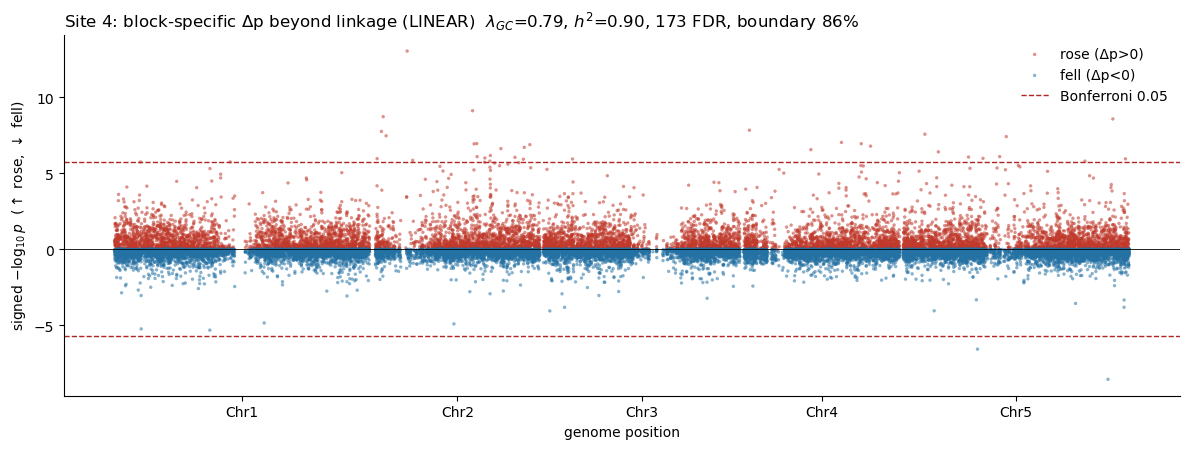

In [3]:
# --- directional Manhattan (signed by the sign of Δp) ---
g2=d.copy(); g2["mid"]=(g2.unit_start+g2.unit_end)/2
g2=g2.sort_values(["chrom","unit_start"]).reset_index(drop=True)
off,centers,x=0.0,[],np.zeros(len(g2))
for ch in CHROMS:
    mk=(g2.chrom==ch).to_numpy()
    if not mk.any(): continue
    x[mk]=g2.mid[mk]+off; centers.append(off+g2.mid[mk].max()/2); off+=g2.mid[mk].max()*1.02
g2["x"]=x
signed=np.sign(g2.s.values)*-np.log10(np.clip(g2.p,1e-300,1)); up=g2.s.values>0
fig,ax=plt.subplots(figsize=(12,4.6))
ax.scatter(g2.x[up],signed[up],s=6,c="#c0392b",alpha=.55,edgecolors="none",label="rose (Δp>0)")
ax.scatter(g2.x[~up],signed[~up],s=6,c="#2471a3",alpha=.55,edgecolors="none",label="fell (Δp<0)")
ax.axhline(0,color="k",lw=.6)
ax.axhline(-np.log10(bonf),color="firebrick",lw=1,ls="--",label="Bonferroni 0.05"); ax.axhline(np.log10(bonf),color="firebrick",lw=1,ls="--")
ax.set_xticks(centers); ax.set_xticklabels(CHROMS)
ax.set_ylabel(r"signed $-\log_{10}p$  ($\uparrow$ rose, $\downarrow$ fell)"); ax.set_xlabel("genome position")
ax.set_title(f"Site {SITE}: block-specific Δp beyond linkage (LINEAR)  "
             f"$\lambda_{{GC}}$={lam_gc:.2f}, $h^2$={h2:.2f}, {int((d.q<0.05).sum())} FDR, boundary {100*bdry:.0f}%",loc="left")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

## QQ plot — calibration of the residual test

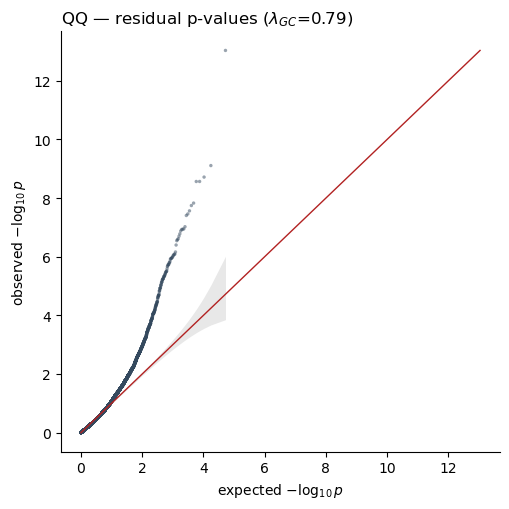

In [4]:
# --- QQ plot of residual p-values (Beta order-statistic 95% band) ---
from scipy.stats import beta as _beta
pv=np.sort(d.p.values); exp=-np.log10((np.arange(1,m+1)-0.5)/m); obs=-np.log10(np.clip(pv,1e-300,1))
fig,ax=plt.subplots(figsize=(5.2,5.2))
ax.scatter(exp,obs,s=6,c="#34495e",alpha=.5,edgecolors="none")
lim=max(exp.max(),obs.max()); ax.plot([0,lim],[0,lim],color="firebrick",lw=1)
_i=np.arange(1,m+1); _lo=_beta.ppf(0.025,_i,m-_i+1); _hi=_beta.ppf(0.975,_i,m-_i+1)
ax.fill_between(exp,-np.log10(np.clip(_hi,1e-300,1)),-np.log10(np.clip(_lo,1e-300,1)),color="grey",alpha=.18,lw=0)
ax.set_xlabel(r"expected $-\log_{10}p$"); ax.set_ylabel(r"observed $-\log_{10}p$")
ax.set_title(f"QQ — residual p-values ($\lambda_{{GC}}$={lam_gc:.2f})",loc="left")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

## Calibration & hits by minor-allele frequency (the remaining caveat)

In [5]:
# --- diagnostic: calibration & hits stratified by MAF (the remaining issue) ---
d["maf"]=np.minimum(d.panel_freq,1-d.panel_freq)
def lam(p): c=stats.chi2.isf(np.clip(p,1e-300,1),1); return np.median(c)/stats.chi2.ppf(0.5,1)
rows=[]
for lo,hi in [(0.05,0.10),(0.10,0.20),(0.20,0.30),(0.30,0.40),(0.40,0.50)]:
    g=d[d.maf.between(lo,hi)]
    rows.append({"MAF":f"[{lo:.2f},{hi:.2f}]","n":len(g),"lambda_GC":round(lam(g.p),2),
                 "FDR_hits":int((g.q<0.05).sum()),"mean|s|":round(g.s.abs().mean(),4)})
pd.DataFrame(rows)

,MAF,n,lambda_GC,FDR_hits,mean|s|
0,"[0.05,0.10]",7312,0.72,148,0.0362
1,"[0.10,0.20]",9393,0.45,10,0.0491
2,"[0.20,0.30]",5237,1.08,7,0.0575
3,"[0.30,0.40]",3013,2.34,5,0.0629
4,"[0.40,0.50]",1288,3.42,3,0.0666


## Top block-specific blocks

In [6]:
# --- top block-specific blocks (linear) ---
d.sort_values("p").head(15)[["chrom","unit_start","unit_end","panel_freq","s","se","linked_bg","resid","z","p","q"]]

,chrom,unit_start,unit_end,panel_freq,s,se,linked_bg,resid,z,p,q
0,Chr2,3809495,3911071,0.05195,0.041442,0.007552,0.160794,-0.109037,-7.451847,9.204276e-14,2.415478e-09
1,Chr2,11645026,11651439,0.05195,0.071965,0.011014,0.184879,-0.102600,-6.149339,7.780631e-10,1.020936e-05
2,Chr2,1003416,1006586,0.05195,0.045613,0.008094,0.145508,-0.089580,-6.004225,1.922477e-09,1.425880e-05
3,Chr5,25008464,25017802,0.05195,0.098582,0.011647,0.210661,-0.101765,-5.948010,2.714215e-09,1.425880e-05
4,Chr5,24431218,24432490,0.94805,-0.130013,0.012100,-0.223315,0.103616,5.947861,2.716686e-09,1.425880e-05
5,Chr4,643015,671647,0.05195,0.128836,0.010894,0.233199,-0.094049,-5.663745,1.481047e-08,6.477852e-05
6,Chr2,796841,801108,0.05195,0.076869,0.011581,0.183265,-0.096082,-5.630601,1.795829e-08,6.732562e-05
7,Chr5,2613521,2630930,0.06061,0.110173,0.010568,0.211607,-0.091120,-5.558121,2.726944e-08,8.945398e-05
8,Chr2,1337304,1363207,0.05628,0.090168,0.008449,0.183850,-0.083367,-5.515667,3.474593e-08,1.013153e-04
9,Chr5,12311263,12315598,0.06494,0.081368,0.008207,0.173992,-0.082310,-5.494262,3.923481e-08,1.029639e-04
